# 驾驶员疲劳检测 — 基于 dataset_split 训练与评估

> **加速说明**：Windows 上 `drowsiness-gpu`（DirectML）在本项目实测**比 CPU 更慢**；日常训练请用内核 **`drowsiness`**。要真正用 RTX 4060 加速，请按 [GPU_SETUP_CN.md](GPU_SETUP_CN.md) 配置 **WSL2 + CUDA**。

二分类任务：**Drowsy** / **Non-Drowsy**（`drowsy` / `notdrowsy`，softmax 2 类）

迁移学习主模型：**MobileNetV2**（ImageNet 预训练）

数据目录结构：
```
dataset_split/
  train/  drowsy/, notdrowsy/
  val/    drowsy/, notdrowsy/
  test/   drowsy/, notdrowsy/
```

In [1]:
import os
import sys

# DirectML 设备索引须在 import tensorflow 之前设置。
# - 独显直连 / 仅 1 块 GPU：用 '0' 或不设置（勿用 '1'，否则会看不到 GPU）
# - 混合模式（核显+独显）：通常为 '1' 选独显；若仍无 GPU 可改为 '0'
if 'DML_VISIBLE_DEVICES' not in os.environ:
    pass  # 不强制，让 DirectML 使用当前可见的唯一 GPU（独显直连）

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('Python:', sys.executable)
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU 设备:', gpus if gpus else '无（当前为 CPU；请换 drowsiness-gpu 内核，见 GPU_SETUP_CN.md）')
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

Python: c:\ProgramData\anaconda3\envs\drowsiness-gpu\python.exe
TensorFlow: 2.10.0
GPU 设备: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
# ---------- 路径与超参数 ----------
PROJECT_ROOT = os.path.abspath('.')
DATA_ROOT = os.path.join(PROJECT_ROOT, 'dataset_split')
TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR = os.path.join(DATA_ROOT, 'val')
TEST_DIR = os.path.join(DATA_ROOT, 'test')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
BASELINE_EPOCHS = 10
MOBILENET_EPOCHS = 25

for name, path in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    assert os.path.isdir(path), f'缺少目录: {path}'
    n_d = sum(len(files) for _, _, files in os.walk(os.path.join(path, 'drowsy')))
    n_n = sum(len(files) for _, _, files in os.walk(os.path.join(path, 'notdrowsy')))
    print(f'{name}: drowsy={n_d}, notdrowsy={n_n}, total={n_d + n_n}')

# 类别不平衡：全猜 drowsy 时准确率 ≈ 54.16%，需 class_weight 避免塌缩到多数类
_n_d = sum(len(files) for _, _, files in os.walk(os.path.join(TRAIN_DIR, 'drowsy')))
_n_n = sum(len(files) for _, _, files in os.walk(os.path.join(TRAIN_DIR, 'notdrowsy')))
_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=np.array([0] * _n_d + [1] * _n_n))
CLASS_WEIGHT = {0: float(_weights[0]), 1: float(_weights[1])}
print('class_weight:', CLASS_WEIGHT)
print('多数类基线准确率 (全猜 drowsy):', round(_n_d / (_n_d + _n_n), 4))

train: drowsy=25221, notdrowsy=21343, total=46564
val: drowsy=5404, notdrowsy=4573, total=9977
test: drowsy=5405, notdrowsy=4575, total=9980
class_weight: {0: 0.9231196225367749, 1: 1.0908494588389637}
多数类基线准确率 (全猜 drowsy): 0.5416


## 1. 数据加载

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
)
val_gen = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)
test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)

class_names = list(train_gen.class_indices.keys())
print('类别映射:', train_gen.class_indices)

Found 46564 images belonging to 2 classes.
Found 9977 images belonging to 2 classes.
Found 9980 images belonging to 2 classes.
类别映射: {'drowsy': 0, 'notdrowsy': 1}


## 2. Baseline CNN 模型

In [4]:
# l2(0.01) 过强会把权重压向 0，模型易塌缩为“全猜多数类”；改用较轻正则 + Adam
L2_REG = 1e-4
model_baseline = Sequential([
    Conv2D(32, (3, 3), input_shape=(*IMG_SIZE, 3), activation='relu', kernel_regularizer=l2(L2_REG)),
    MaxPooling2D(pool_size=(2, 2), padding='same'),
    Conv2D(32, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(L2_REG)),
    MaxPooling2D(pool_size=(2, 2), padding='same'),
    Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(L2_REG)),
    MaxPooling2D(pool_size=(2, 2), padding='same'),
    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=l2(L2_REG)),
    Dropout(0.5),
    Dense(2, activation='softmax'),
])
model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model_baseline.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 111, 111, 32)      9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 28, 28, 64)       0

In [5]:
history_baseline = model_baseline.fit(
    train_gen,
    epochs=BASELINE_EPOCHS,
    validation_data=val_gen,
    class_weight=CLASS_WEIGHT,
    verbose=1,
)
# TF 2.10（GPU 环境）请用 .h5；TF 2.21 也兼容
model_baseline.save('model_baseline.h5')

Epoch 1/10
1456/1456 [==============================] - 289s 197ms/step - loss: 0.5574 - accuracy: 0.7073 - val_loss: 0.3917 - val_accuracy: 0.8139
Epoch 2/10
1456/1456 [==============================] - 279s 192ms/step - loss: 0.4319 - accuracy: 0.7995 - val_loss: 0.3350 - val_accuracy: 0.8482
Epoch 3/10
1456/1456 [==============================] - 285s 196ms/step - loss: 0.3849 - accuracy: 0.8225 - val_loss: 0.2865 - val_accuracy: 0.8700
Epoch 4/10
1456/1456 [==============================] - 275s 189ms/step - loss: 0.3570 - accuracy: 0.8328 - val_loss: 0.2728 - val_accuracy: 0.8740
Epoch 5/10
1456/1456 [==============================] - 295s 203ms/step - loss: 0.3350 - accuracy: 0.8405 - val_loss: 0.2609 - val_accuracy: 0.8788
Epoch 6/10
1456/1456 [==============================] - 281s 193ms/step - loss: 0.3137 - accuracy: 0.8524 - val_loss: 0.2300 - val_accuracy: 0.8972
Epoch 7/10
1456/1456 [==============================] - 289s 199ms/step - loss: 0.3022 - accuracy: 0.8565 - val_

## 3. MobileNetV2 迁移学习模型

In [6]:
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(*IMG_SIZE, 3),
)
mobilenet_base.trainable = False

model_mobilenet = Sequential([
    mobilenet_base,
    Flatten(),
    Dense(1024, activation='relu', kernel_regularizer=l2(L2_REG)),
    Dense(512, activation='relu', kernel_regularizer=l2(L2_REG)),
    Dense(2, activation='softmax'),  # Drowsy / Non-Drowsy
])
model_mobilenet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model_mobilenet.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 flatten_1 (Flatten)         (None, 62720)             0         
                                                                 
 dense_2 (Dense)             (None, 1024)              64226304  
                                                                 
 dense_3 (Dense)             (None, 512)               524800    
                                                                 
 dense_4 (Dense)             (None, 2)                 1026      
                                                                 
Total params: 67,010,114
Trainable params: 64,752,130
Non-trainable params: 2,257,984
__________________________________

In [9]:
history_mobilenet = model_mobilenet.fit(
    train_gen,
    epochs=MOBILENET_EPOCHS,
    validation_data=val_gen,
    class_weight=CLASS_WEIGHT,
    verbose=1,
)
model_mobilenet.save('model_mobilenetv2.h5')

Epoch 1/25
1456/1456 [==============================] - 273s 187ms/step - loss: 0.4159 - accuracy: 0.8853 - val_loss: 0.3312 - val_accuracy: 0.9099
Epoch 2/25
1456/1456 [==============================] - 277s 190ms/step - loss: 0.3119 - accuracy: 0.9115 - val_loss: 0.2918 - val_accuracy: 0.9082
Epoch 3/25
1456/1456 [==============================] - 275s 189ms/step - loss: 0.2549 - accuracy: 0.9234 - val_loss: 0.2504 - val_accuracy: 0.9238
Epoch 4/25
1456/1456 [==============================] - 277s 190ms/step - loss: 0.2142 - accuracy: 0.9309 - val_loss: 0.2119 - val_accuracy: 0.9285
Epoch 5/25
1456/1456 [==============================] - 277s 190ms/step - loss: 0.1908 - accuracy: 0.9375 - val_loss: 0.2144 - val_accuracy: 0.9313
Epoch 6/25
1456/1456 [==============================] - 276s 190ms/step - loss: 0.1752 - accuracy: 0.9402 - val_loss: 0.1643 - val_accuracy: 0.9442
Epoch 7/25
1456/1456 [==============================] - 278s 191ms/step - loss: 0.1583 - accuracy: 0.9461 - val_

## 4. 训练曲线可视化

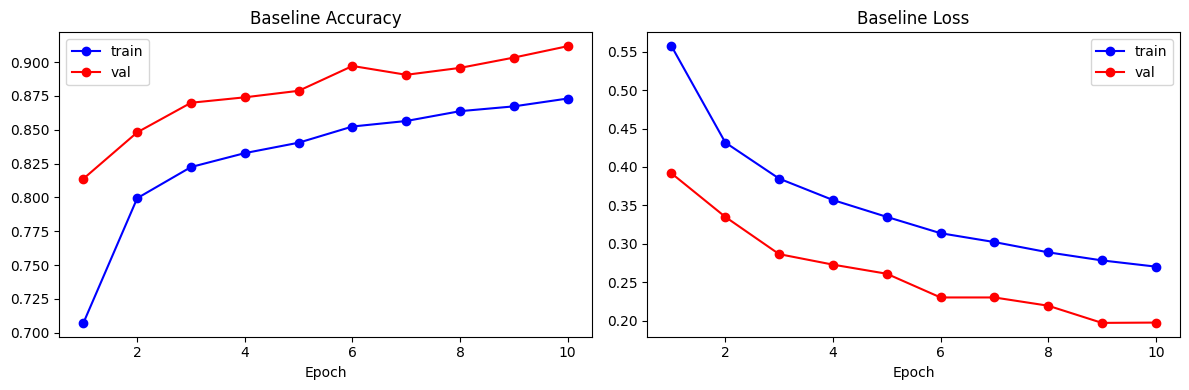

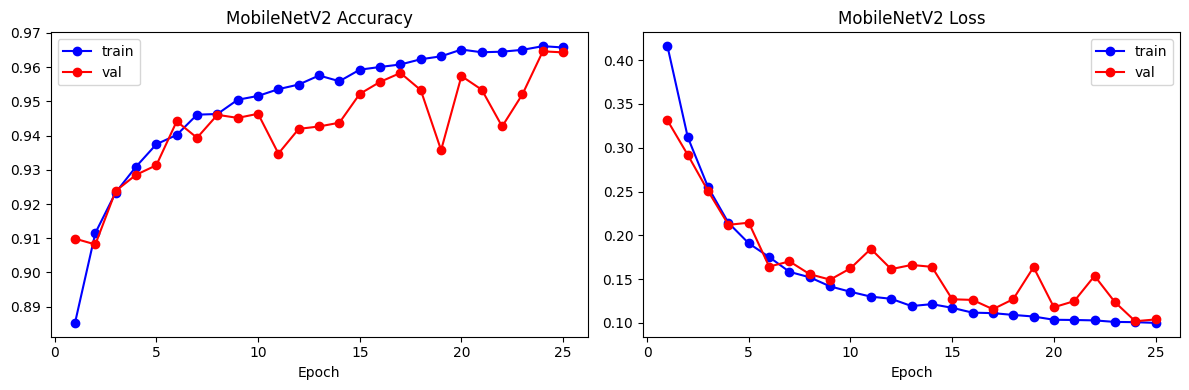

In [11]:
# 若曾导入失败，先清除损坏的 matplotlib 缓存再重装后 Restart Kernel
if 'matplotlib' in sys.modules and not hasattr(sys.modules['matplotlib'], 'get_data_path'):
    del sys.modules['matplotlib']

%matplotlib inline
import matplotlib.pyplot as plt


def plot_history(history, title_prefix=''):
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_' + acc_key
    epochs = range(1, len(history.history[acc_key]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history.history[acc_key], 'b-o', label='train')
    axes[0].plot(epochs, history.history[val_acc_key], 'r-o', label='val')
    axes[0].set_title(f'{title_prefix} Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs, history.history['loss'], 'b-o', label='train')
    axes[1].plot(epochs, history.history['val_loss'], 'r-o', label='val')
    axes[1].set_title(f'{title_prefix} Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_baseline, 'Baseline')
plot_history(history_mobilenet, 'MobileNetV2')

## 5. 测试集分类结果

In [12]:
def evaluate_model(model, generator, model_name):
    generator.reset()
    y_prob = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes

    print(f'\n===== {model_name} · 测试集 =====')
    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4,
    ))
    cm = confusion_matrix(y_true, y_pred)
    print('混淆矩阵 (行=真实, 列=预测):')
    print(cm)
    return y_true, y_pred

# _, _ = evaluate_model(model_baseline, test_gen, 'Baseline CNN')
test_gen.reset()
_, _ = evaluate_model(model_mobilenet, test_gen, 'MobileNetV2')

312/312 [==============================] - 18s 56ms/step

===== MobileNetV2 · 测试集 =====
              precision    recall  f1-score   support

      drowsy     0.9632    0.9747    0.9689      5405
   notdrowsy     0.9696    0.9561    0.9628      4575

    accuracy                         0.9661      9980
   macro avg     0.9664    0.9654    0.9659      9980
weighted avg     0.9662    0.9661    0.9661      9980

混淆矩阵 (行=真实, 列=预测):
[[5268  137]
 [ 201 4374]]
